<a href="https://www.arduino.cc/"><img src="https://raw.githubusercontent.com/sandeepmistry/aimldevfest-workshop-2019/master/images/Arduino_logo_R_highquality.png" width=200/></a>
# Tiny ML on Arduino
## Gesture recognition tutorial
 * Sandeep Mistry - Arduino
 * Don Coleman - Chariot Solutions


https://github.com/arduino/ArduinoTensorFlowLiteTutorials/

## Setup Python Environment

The next cell sets up the dependencies in required for the notebook, run it.

In [ ]:
# Setup environment
!apt-get -qq install xxd
!pip install pandas numpy matplotlib
!pip install tensorflow

# Upload Data

1. Open the panel on the left side of Colab by clicking on the __>__
1. Select the files tab
1. Drag `punch.csv` and `flex.csv` files from your computer to the tab to upload them into colab.

# Graph Data (optional)

We'll graph the input files on two separate graphs, acceleration and gyroscope, as each data set has different units and scale.

/tmp/ipykernel_157/3341400847.py:13: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "g." (-> marker='.'). The keyword argument will take precedence.
  plt.plot(index, df['aX'], 'g.', label='x', linestyle='solid', marker=',')
/tmp/ipykernel_157/3341400847.py:14: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "b." (-> marker='.'). The keyword argument will take precedence.
  plt.plot(index, df['aY'], 'b.', label='y', linestyle='solid', marker=',')
/tmp/ipykernel_157/3341400847.py:15: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "r." (-> marker='.'). The keyword argument will take precedence.
  plt.plot(index, df['aZ'], 'r.', label='z', linestyle='solid', marker=',')


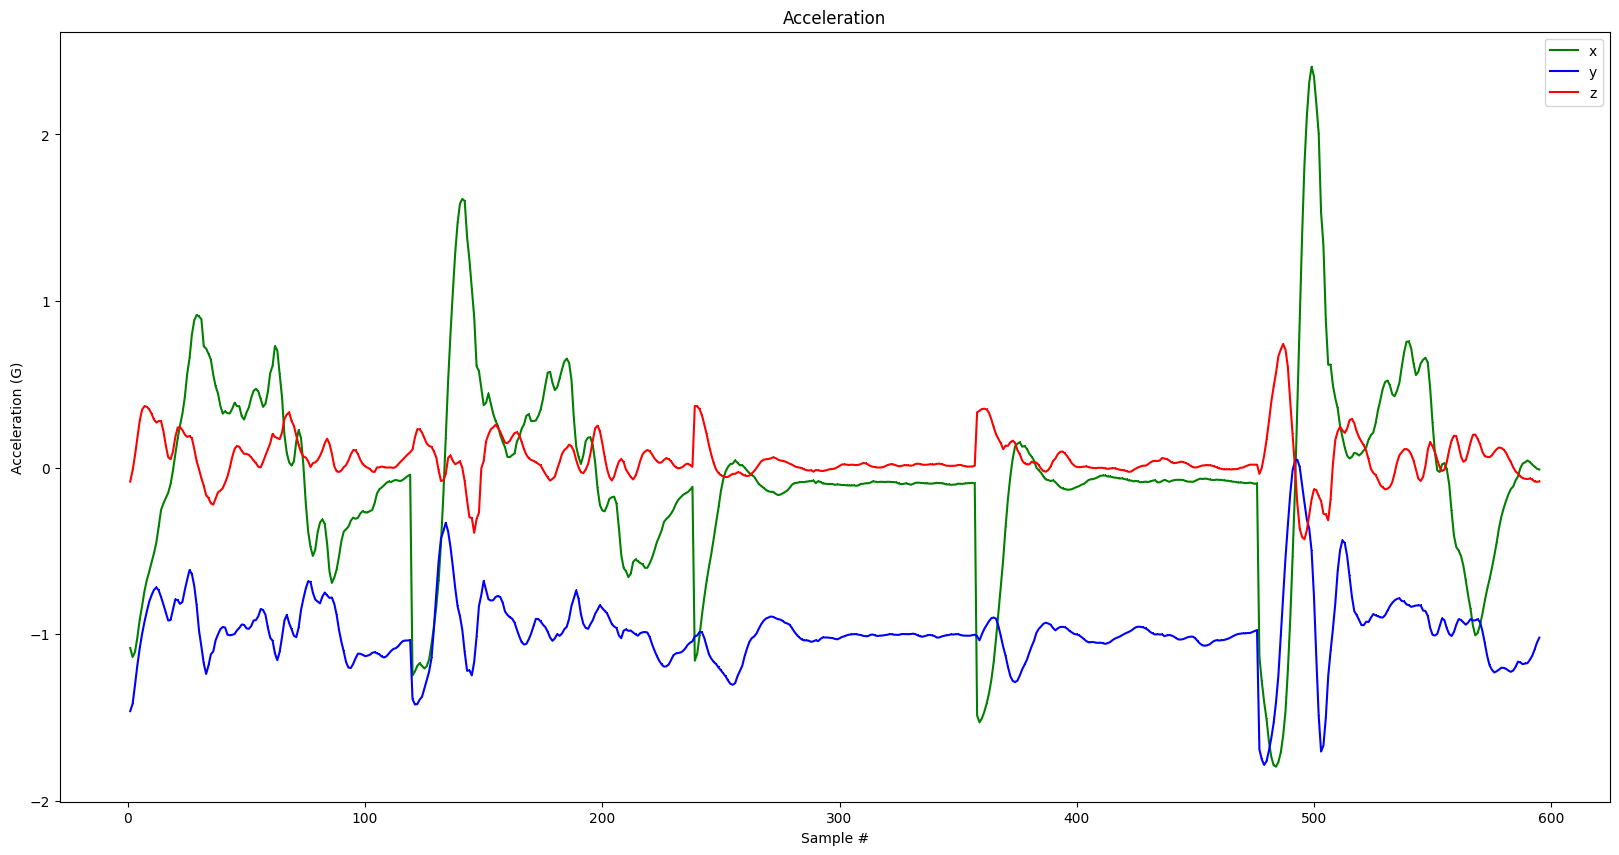

/tmp/ipykernel_157/3341400847.py:22: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "g." (-> marker='.'). The keyword argument will take precedence.
  plt.plot(index, df['gX'], 'g.', label='x', linestyle='solid', marker=',')
/tmp/ipykernel_157/3341400847.py:23: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "b." (-> marker='.'). The keyword argument will take precedence.
  plt.plot(index, df['gY'], 'b.', label='y', linestyle='solid', marker=',')
/tmp/ipykernel_157/3341400847.py:24: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "r." (-> marker='.'). The keyword argument will take precedence.
  plt.plot(index, df['gZ'], 'r.', label='z', linestyle='solid', marker=',')


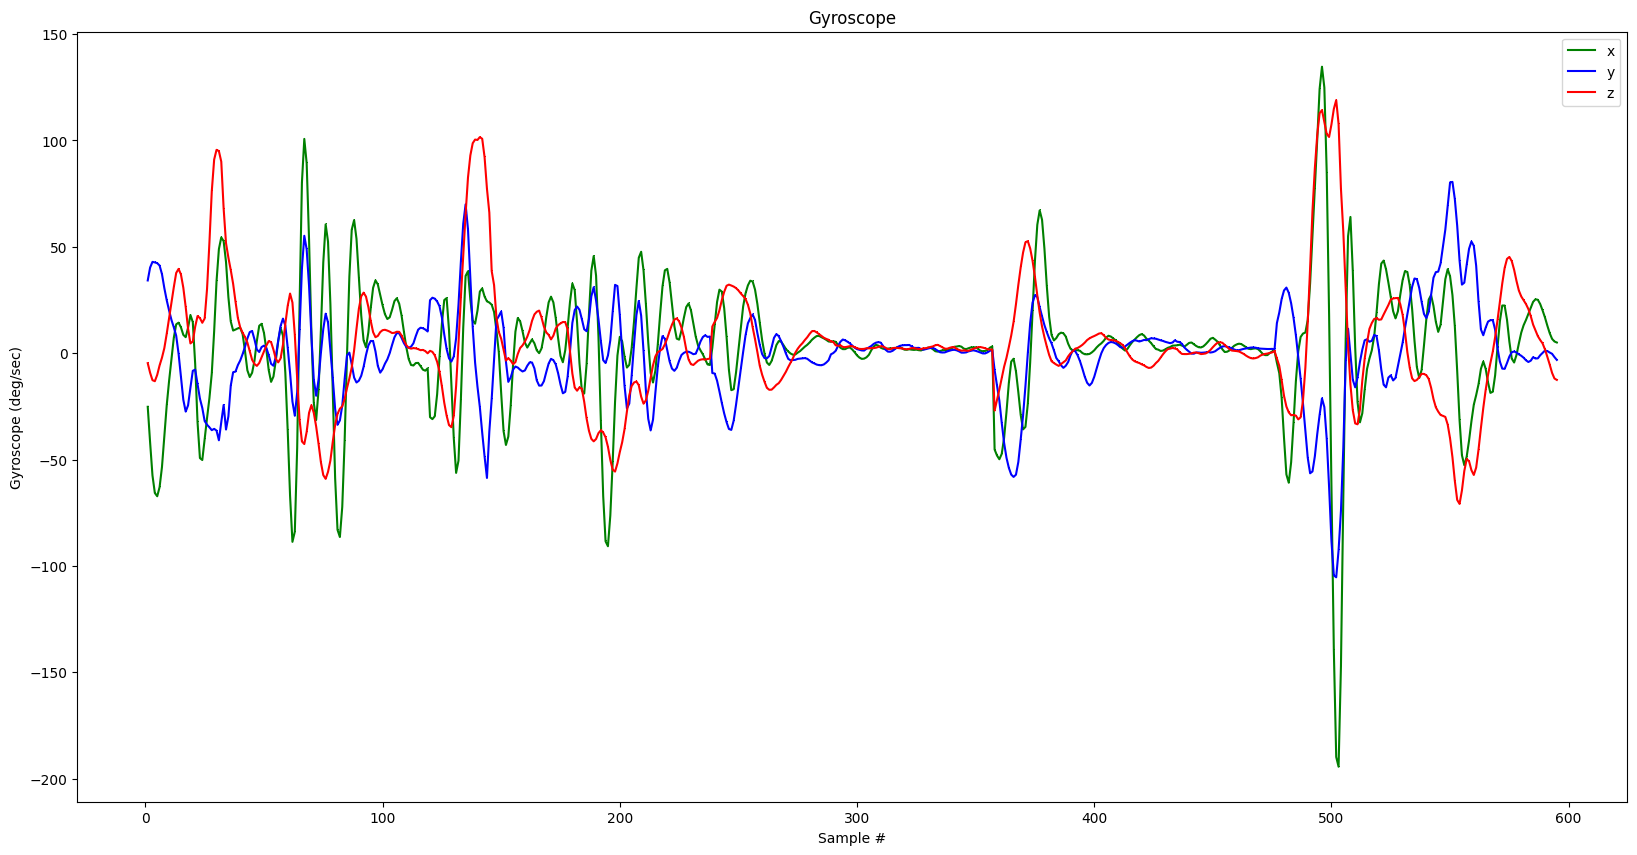

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

filename = "Punch.csv"

df = pd.read_csv("/content/" + filename)

index = range(1, len(df['aX']) + 1)

plt.rcParams["figure.figsize"] = (20,10)

plt.plot(index, df['aX'], 'g.', label='x', linestyle='solid', marker=',')
plt.plot(index, df['aY'], 'b.', label='y', linestyle='solid', marker=',')
plt.plot(index, df['aZ'], 'r.', label='z', linestyle='solid', marker=',')
plt.title("Acceleration")
plt.xlabel("Sample #")
plt.ylabel("Acceleration (G)")
plt.legend()
plt.show()

plt.plot(index, df['gX'], 'g.', label='x', linestyle='solid', marker=',')
plt.plot(index, df['gY'], 'b.', label='y', linestyle='solid', marker=',')
plt.plot(index, df['gZ'], 'r.', label='z', linestyle='solid', marker=',')
plt.title("Gyroscope")
plt.xlabel("Sample #")
plt.ylabel("Gyroscope (deg/sec)")
plt.legend()
plt.show()


# Train Neural Network





##Configuration

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import confusion_matrix

print(f"TensorFlow version = {tf.__version__}\n")

# --- Configuration ---
GESTURES = ["Punch", "Flex", "Shake", "UpDown", "Circle"]
SAMPLES_PER_GESTURE = 119
WINDOW_SIZE = 20          # samples per sliding window
SEED = 1337
EPOCHS = 600
BATCH_SIZE = 1
TRAIN_RATIO = 0.6
VAL_RATIO = 0.2
TEST_RATIO = 0.2
IMU_AXES = ['aX', 'aY', 'aZ', 'gX', 'gY', 'gZ']
NUM_TIME_FEATURES = 5     # mean, std, rms, min, max
NUM_FREQ_FEATURES = 1     # PSD
FEATURES_PER_WINDOW = (NUM_TIME_FEATURES + NUM_FREQ_FEATURES) * len(IMU_AXES)  # 36

# Set a fixed random seed value, for reproducibility, this will allow us to get
# the same random numbers each time the notebook is run
np.random.seed(SEED)
tf.random.set_seed(SEED)

NUM_GESTURES = len(GESTURES)

TensorFlow version = 2.19.0



##Functions Declaration

In [ ]:
def one_hot_encode(index: int, num_classes: int) -> np.ndarray:
    """Return a one-hot vector of length *num_classes* with a 1.0 at *index*."""
    vec = np.zeros(num_classes)
    vec[index] = 1.0
    return vec


def load_gesture_csv(gesture_name: str) -> pd.DataFrame:
    """Load a gesture CSV file and validate required IMU columns.

    Reads /content/{gesture_name}.csv and checks that columns
    aX, aY, aZ, gX, gY, gZ are present.

    Args:
        gesture_name: Name of the gesture (used to build the file path).

    Returns:
        A pandas DataFrame with the CSV data.

    Raises:
        FileNotFoundError: If the CSV file does not exist.
        ValueError: If any required IMU columns are missing.
    """
    filepath = f"/content/{gesture_name}.csv"
    try:
        df = pd.read_csv(filepath)
    except FileNotFoundError:
        raise FileNotFoundError(f"CSV file not found: {filepath}")

    required_columns = set(IMU_AXES)
    missing = required_columns - set(df.columns)
    if missing:
        raise ValueError(
            f"Missing required columns in {filepath}: {sorted(missing)}"
        )
    return df


def segment_into_windows(data: np.ndarray, window_size: int) -> np.ndarray:
    """Divide a 2D array of IMU samples into non-overlapping fixed-size windows.

    Args:
        data: 2D array of shape (N, 6) containing IMU samples.
        window_size: Number of rows per window.

    Returns:
        3D array of shape (num_windows, window_size, 6). Trailing samples
        that do not fill a complete window are discarded. Returns an empty
        array of shape (0, window_size, 6) when N < window_size.
    """
    num_samples = data.shape[0]
    num_channels = data.shape[1]
    num_windows = num_samples // window_size
    if num_windows == 0:
        return np.empty((0, window_size, num_channels))
    trimmed = data[:num_windows * window_size]
    return trimmed.reshape(num_windows, window_size, num_channels)

def compute_time_features(window: np.ndarray) -> np.ndarray:
    """Compute per-axis time-domain features: mean, std, RMS, min, max.

    Args:
        window: 2D array of shape (W, 6) containing one window of IMU data.

    Returns:
        1D array of shape (30,) — 5 features × 6 axes, ordered as
        [mean_ax, mean_ay, ..., std_ax, ..., rms_ax, ..., min_ax, ..., max_ax, ...].
    """
    means = np.mean(window, axis=0)
    stds = np.std(window, axis=0)
    rms = np.sqrt(np.mean(window ** 2, axis=0))
    mins = np.min(window, axis=0)
    maxs = np.max(window, axis=0)
    return np.concatenate([means, stds, rms, mins, maxs])


def compute_psd(window: np.ndarray) -> np.ndarray:
    """Compute per-axis mean Power Spectral Density via FFT.

    PSD for each axis is the mean of |FFT|² (squared magnitude of the full
    FFT) for that axis column.

    Args:
        window: 2D array of shape (W, 6) containing one window of IMU data.

    Returns:
        1D array of shape (6,) — one PSD value per axis.
    """
    fft_vals = np.fft.fft(window, axis=0)
    power = np.abs(fft_vals) ** 2
    return np.mean(power, axis=0)

def extract_features(window: np.ndarray) -> np.ndarray:
    """Concatenate time-domain and frequency-domain features for one window.

    Args:
        window: 2D array of shape (W, 6) containing one window of IMU data.

    Returns:
        1D array of length 36 (30 time-domain + 6 frequency-domain features).
    """
    time_feats = compute_time_features(window)
    freq_feats = compute_psd(window)
    return np.concatenate([time_feats, freq_feats])


def compute_normalization_params(features: np.ndarray) -> tuple:
    """Compute per-feature mean and standard deviation for z-score normalization.

    Args:
        features: 2D array of shape (N, 36) containing feature vectors.

    Returns:
        Tuple of (means, stds), each a 1D array of shape (36,).
    """
    means = np.mean(features, axis=0)
    stds = np.std(features, axis=0)
    return means, stds


def normalize(features: np.ndarray, means: np.ndarray, stds: np.ndarray) -> np.ndarray:
    """Apply z-score normalization to feature vectors.

    Where std == 0, the normalized value is set to 0.0 instead of dividing by zero.

    Args:
        features: 2D array of shape (N, 36) containing feature vectors.
        means: 1D array of shape (36,) with per-feature means.
        stds: 1D array of shape (36,) with per-feature standard deviations.

    Returns:
        2D array of shape (N, 36) with z-score normalized features.
    """
    return np.where(stds == 0, 0.0, (features - means) / stds)


def build_model(input_dim: int, num_classes: int) -> tf.keras.Model:
    """Build and compile a fully connected neural network for gesture classification.

    Creates a Sequential model with two hidden layers (50 and 15 neurons, both
    ReLU) and a softmax output layer, compiled with the RMSprop optimizer and
    mean-squared-error loss.

    Args:
        input_dim: Number of input features (e.g. 36).
        num_classes: Number of gesture classes for the output layer.

    Returns:
        A compiled tf.keras.Model ready for training.
    """
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Dense(50, activation='relu', input_shape=(input_dim,)))
    model.add(tf.keras.layers.Dense(15, activation='relu'))
    model.add(tf.keras.layers.Dense(num_classes, activation='softmax'))
    model.compile(optimizer='rmsprop', loss='mse', metrics=['mae'])
    return model

def evaluate_model(model, X_test, y_test, gesture_names):
    """Evaluate the model on test data, print accuracy, and display a confusion matrix heatmap.

    Args:
        model: A trained Keras model.
        X_test: 2D array of shape (N, 36) with normalized test features.
        y_test: 2D array of shape (N, num_classes) with one-hot encoded test labels.
        gesture_names: List of gesture class name strings.
    """
    predictions = model.predict(X_test)
    y_pred = np.argmax(predictions, axis=1)
    y_true = np.argmax(y_test, axis=1)

    accuracy = np.mean(y_pred == y_true) * 100.0
    print(f"Test accuracy: {accuracy:.2f}%")

    cm = confusion_matrix(y_true, y_pred, labels=range(len(gesture_names)))

    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    ax.figure.colorbar(im, ax=ax)
    ax.set(
        xticks=range(len(gesture_names)),
        yticks=range(len(gesture_names)),
        xticklabels=gesture_names,
        yticklabels=gesture_names,
        xlabel='Predicted label',
        ylabel='True label',
        title='Confusion Matrix',
    )
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')

    # Annotate cells with counts
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]),
                    ha='center', va='center',
                    color='white' if cm[i, j] > cm.max() / 2 else 'black')
    fig.tight_layout()
    plt.show()

def export_model_params(model, means, stds, gesture_names, filepath):
    """Export trained model weights, biases, normalization params, and gesture names as a C header file.

    Iterates over Dense layers in the model, extracts weights and biases,
    and writes them as const float C arrays. Also writes normalization
    parameters and gesture names for Arduino deployment.

    Args:
        model: A trained Keras Sequential model.
        means: 1D array of shape (F,) with per-feature means.
        stds: 1D array of shape (F,) with per-feature standard deviations.
        gesture_names: List of gesture class name strings.
        filepath: Output file path for the C header.
    """
    # Collect Dense layer weights/biases
    layers_info = []
    for layer in model.layers:
        weights = layer.get_weights()
        if len(weights) == 2:
            w, b = weights
            activation = layer.get_config().get('activation', 'unknown')
            layers_info.append((w, b, activation))

    num_layers = len(layers_info)
    input_dim = layers_info[0][0].shape[0] if num_layers > 0 else 0
    num_classes = layers_info[-1][1].shape[0] if num_layers > 0 else 0

    def _format_array(arr, name, shape_comment):
        """Format a flat or 2D array as a C const float declaration."""
        flat = arr.flatten()
        values = ', '.join(f'{v:.8f}f' for v in flat)
        return f'// {shape_comment}\nconst float {name}[] = {{{values}}};\n'

    with open(filepath, 'w') as f:
        f.write('// Auto-generated model parameters header\n')
        f.write('// Architecture metadata\n')
        f.write(f'#define NUM_LAYERS {num_layers}\n')
        f.write(f'#define INPUT_DIM {input_dim}\n')
        f.write(f'#define NUM_CLASSES {num_classes}\n')

        layer_sizes = ', '.join(str(b.shape[0]) for _, b, _ in layers_info)
        activations = ', '.join(a for _, _, a in layers_info)
        f.write(f'// Layer sizes: {layer_sizes}\n')
        f.write(f'// Activations: {activations}\n\n')

        # Weights and biases
        f.write('// Weights and biases\n')
        for i, (w, b, _) in enumerate(layers_info):
            rows, cols = w.shape
            f.write(_format_array(w, f'weights_{i}', f'shape: ({rows}, {cols})'))
            f.write(_format_array(b, f'biases_{i}', f'shape: ({b.shape[0]},)'))
            f.write('\n')

        # Normalization parameters
        f.write('// Normalization parameters\n')
        f.write(_format_array(means, 'norm_means', f'shape: ({len(means)},)'))
        f.write(_format_array(stds, 'norm_stds', f'shape: ({len(stds)},)'))
        f.write('\n')

        # Gesture class names
        f.write('// Gesture class names\n')
        names_str = ', '.join(f'"{name}"' for name in gesture_names)
        f.write(f'const char* gesture_names[{len(gesture_names)}] = {{{names_str}}};\n')


## Parse and prepare the data

The next cell parses the csv files and transforms them to a format that will be used to train the fully connected neural network.

Update the `GESTURES` list with the gesture data you've collected in `.csv` format.


In [ ]:
inputs = []
outputs = []

# read each csv file, segment into gesture blocks of SAMPLES_PER_GESTURE,
# then divide each block into windows of WINDOW_SIZE for feature extraction
for gesture_index in range(NUM_GESTURES):
    gesture = GESTURES[gesture_index]
    print(f"Processing index {gesture_index} for gesture '{gesture}'.")

    output = one_hot_encode(gesture_index, NUM_GESTURES)

    df = load_gesture_csv(gesture)
    data = df[IMU_AXES].values

    print(f"\tLoaded {len(data)} samples for gesture '{gesture}'.")

    # Split the full recording into individual gesture blocks of 119 samples
    num_gestures_in_file = len(data) // SAMPLES_PER_GESTURE
    print(f"\tFound {num_gestures_in_file} gesture recordings "
          f"({SAMPLES_PER_GESTURE} samples each).")

    for g in range(num_gestures_in_file):
        gesture_block = data[g * SAMPLES_PER_GESTURE : (g + 1) * SAMPLES_PER_GESTURE]

        # Divide each gesture block into windows for feature extraction
        windows = segment_into_windows(gesture_block, WINDOW_SIZE)

        for window in windows:
            inputs.append(extract_features(window))
            outputs.append(output)

    total_windows = num_gestures_in_file * (SAMPLES_PER_GESTURE // WINDOW_SIZE)
    print(f"\tCreated {total_windows} windows of size {WINDOW_SIZE}.")

# Convert to numpy arrays
inputs = np.array(inputs)
outputs = np.array(outputs)

if inputs.size == 0:
    raise ValueError("No feature vectors were extracted. Check CSV data and window size.")

print(f"Data set parsing and preparation complete. "
      f"Total windows: {len(inputs)}, shape: {inputs.shape}")

Processing index 0 for gesture 'Punch'.
	Loaded 595 samples for gesture 'Punch'.
	Found 5 gesture recordings (119 samples each).
	Created 25 windows of size 20.
Processing index 1 for gesture 'Flex'.
	Loaded 952 samples for gesture 'Flex'.
	Found 8 gesture recordings (119 samples each).
	Created 40 windows of size 20.
Processing index 2 for gesture 'Shake'.
	Loaded 833 samples for gesture 'Shake'.
	Found 7 gesture recordings (119 samples each).
	Created 35 windows of size 20.
Processing index 3 for gesture 'UpDown'.
	Loaded 952 samples for gesture 'UpDown'.
	Found 8 gesture recordings (119 samples each).
	Created 40 windows of size 20.
Processing index 4 for gesture 'Circle'.
	Loaded 952 samples for gesture 'Circle'.
	Found 8 gesture recordings (119 samples each).
	Created 40 windows of size 20.
Data set parsing and preparation complete. Total windows: 180, shape: (180, 36)


## Randomize and split the input and output pairs for training

Randomly split input and output pairs into sets of data: 60% for training, 20% for validation, and 20% for testing.

  - the training set is used to train the model
  - the validation set is used to measure how well the model is performing during training
  - the testing set is used to test the model after training

In [ ]:
# Randomize the order of the inputs, so they can be evenly distributed for training, testing, and validation
# https://stackoverflow.com/a/37710486/2020087
num_inputs = len(inputs)
randomize = np.arange(num_inputs)
np.random.shuffle(randomize)

# Swap the consecutive indexes (0, 1, 2, etc) with the randomized indexes
inputs = inputs[randomize]
outputs = outputs[randomize]

# Split the recordings (group of samples) into three sets: training, testing and validation
TRAIN_SPLIT = int(TRAIN_RATIO * num_inputs)
TEST_SPLIT = TRAIN_SPLIT + int(VAL_RATIO * num_inputs)

inputs_train, inputs_test, inputs_validate = np.split(inputs, [TRAIN_SPLIT, TEST_SPLIT])
outputs_train, outputs_test, outputs_validate = np.split(outputs, [TRAIN_SPLIT, TEST_SPLIT])

print("Data set randomization and splitting complete.")

# Compute normalization params from training set only, then apply to all sets
norm_means, norm_stds = compute_normalization_params(inputs_train)
inputs_train = normalize(inputs_train, norm_means, norm_stds)
inputs_test = normalize(inputs_test, norm_means, norm_stds)
inputs_validate = normalize(inputs_validate, norm_means, norm_stds)

print("Z-score normalization applied.")

Data set randomization and splitting complete.
Z-score normalization applied.


## Build & Train the Model

Build and train a [TensorFlow](https://www.tensorflow.org) model using the high-level [Keras](https://www.tensorflow.org/guide/keras) API.

In [ ]:
# build the model and train it
model = build_model(FEATURES_PER_WINDOW, NUM_GESTURES)
history = model.fit(inputs_train, outputs_train, epochs=EPOCHS, batch_size=BATCH_SIZE, validation_data=(inputs_validate, outputs_validate))



Epoch 1/600


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1595 - mae: 0.3107 - val_loss: 0.1341 - val_mae: 0.2834
Epoch 2/600
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1285 - mae: 0.2759 - val_loss: 0.1070 - val_mae: 0.2444
Epoch 3/600
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1060 - mae: 0.2416 - val_loss: 0.0914 - val_mae: 0.2155
Epoch 4/600
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0916 - mae: 0.2153 - val_loss: 0.0813 - val_mae: 0.1950
Epoch 5/600
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0796 - mae: 0.1931 - val_loss: 0.0723 - val_mae: 0.1770
Epoch 6/600
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0689 - mae: 0.1727 - val_loss: 0.0663 - val_mae: 0.1637
Epoch 7/600
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0597 - mae: 0.1546 - val_loss: 0.0593 - val_mae: 0.1504
Epoch 8/600
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0517 - mae: 0.1379 - val_loss: 0.0548 - val_mae: 0.1393
Epoch 9/600
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss:

## Verify

Graph the models performance vs validation.


### Graph the loss

Graph the loss to see when the model stops improving.

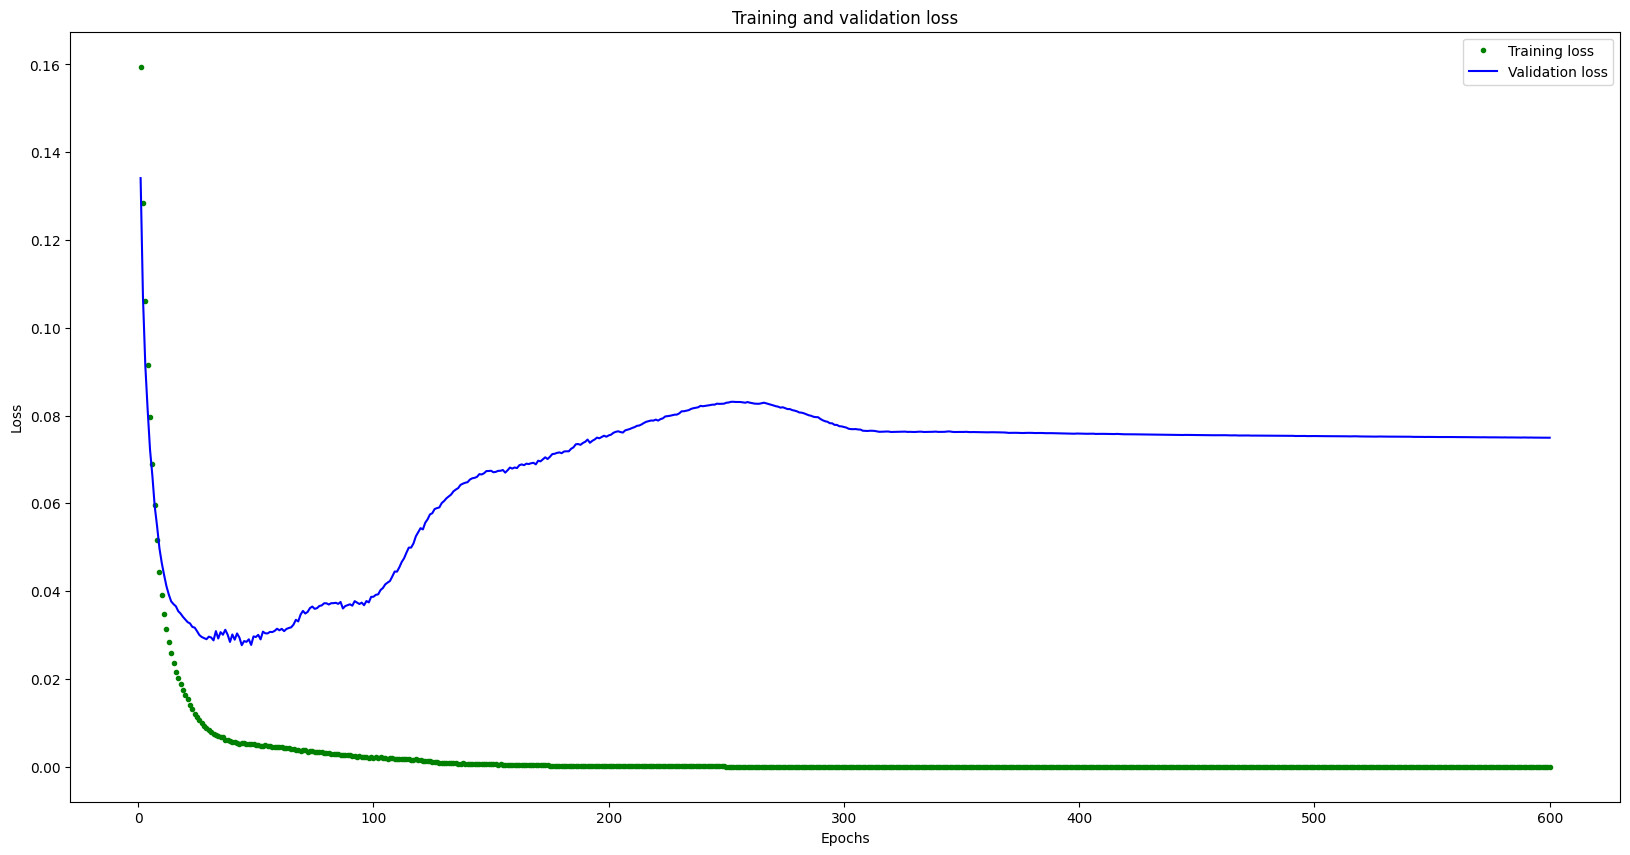

[20.0, 10.0]


In [ ]:
# increase the size of the graphs. The default size is (6,4).
plt.rcParams["figure.figsize"] = (20,10)

# graph the loss, the model above is configure to use "mean squared error" as the loss function
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'g.', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

print(plt.rcParams["figure.figsize"])

### Graph the loss again, skipping a bit of the start

We'll graph the same data as the previous code cell, but start at index 100 so we can further zoom in once the model starts to converge.

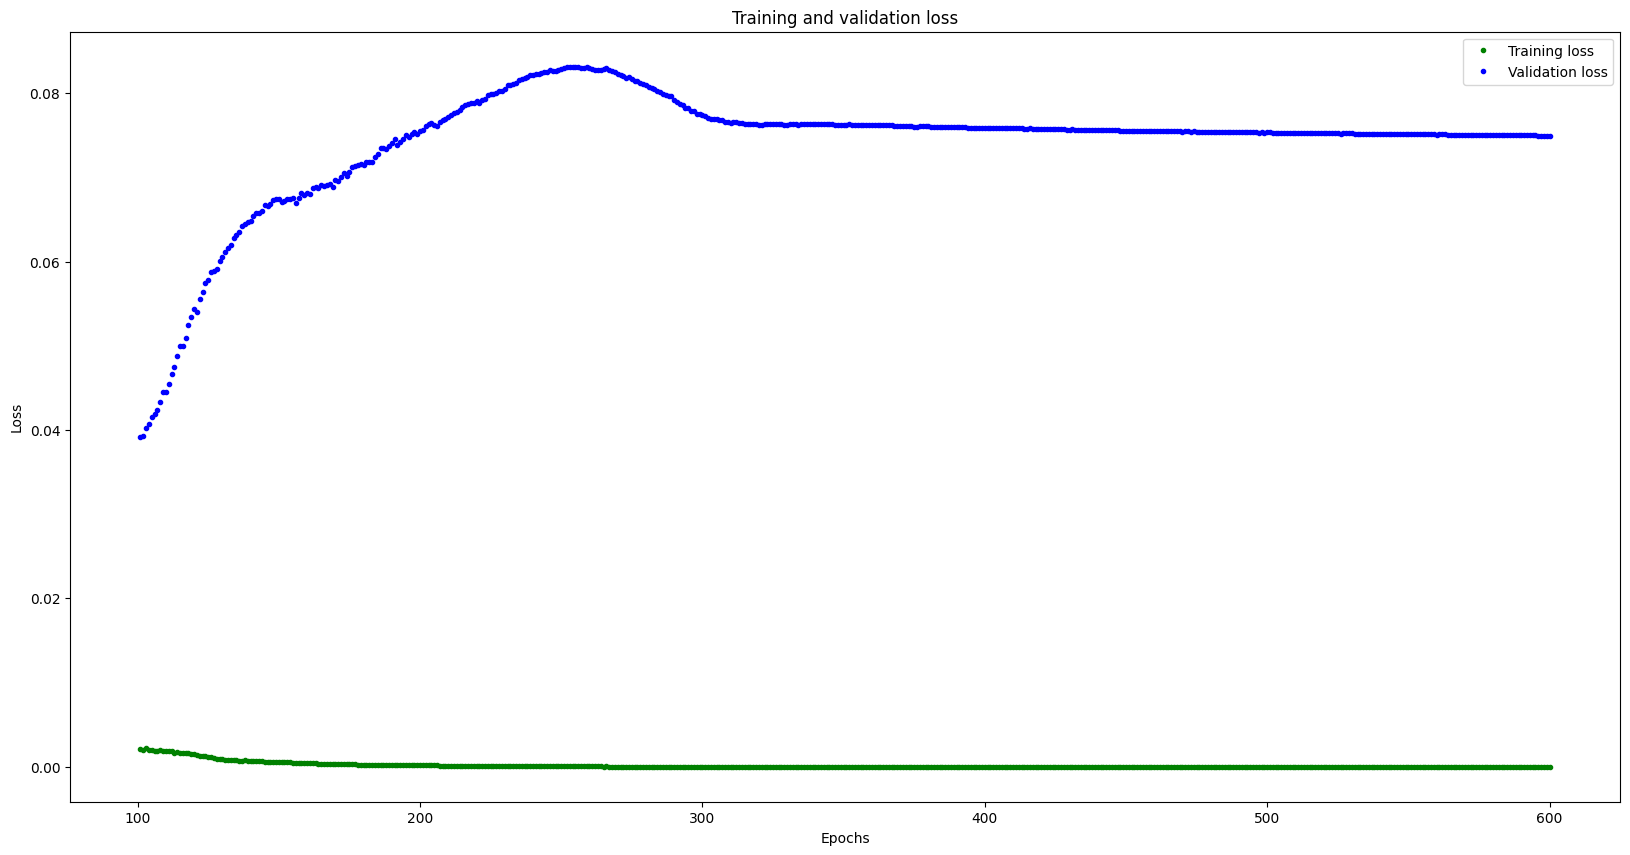

In [ ]:
# graph the loss again skipping a bit of the start
SKIP = 100
plt.plot(epochs[SKIP:], loss[SKIP:], 'g.', label='Training loss')
plt.plot(epochs[SKIP:], val_loss[SKIP:], 'b.', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

### Graph the mean absolute error

[Mean absolute error](https://en.wikipedia.org/wiki/Mean_absolute_error) is another metric to judge the performance of the model.



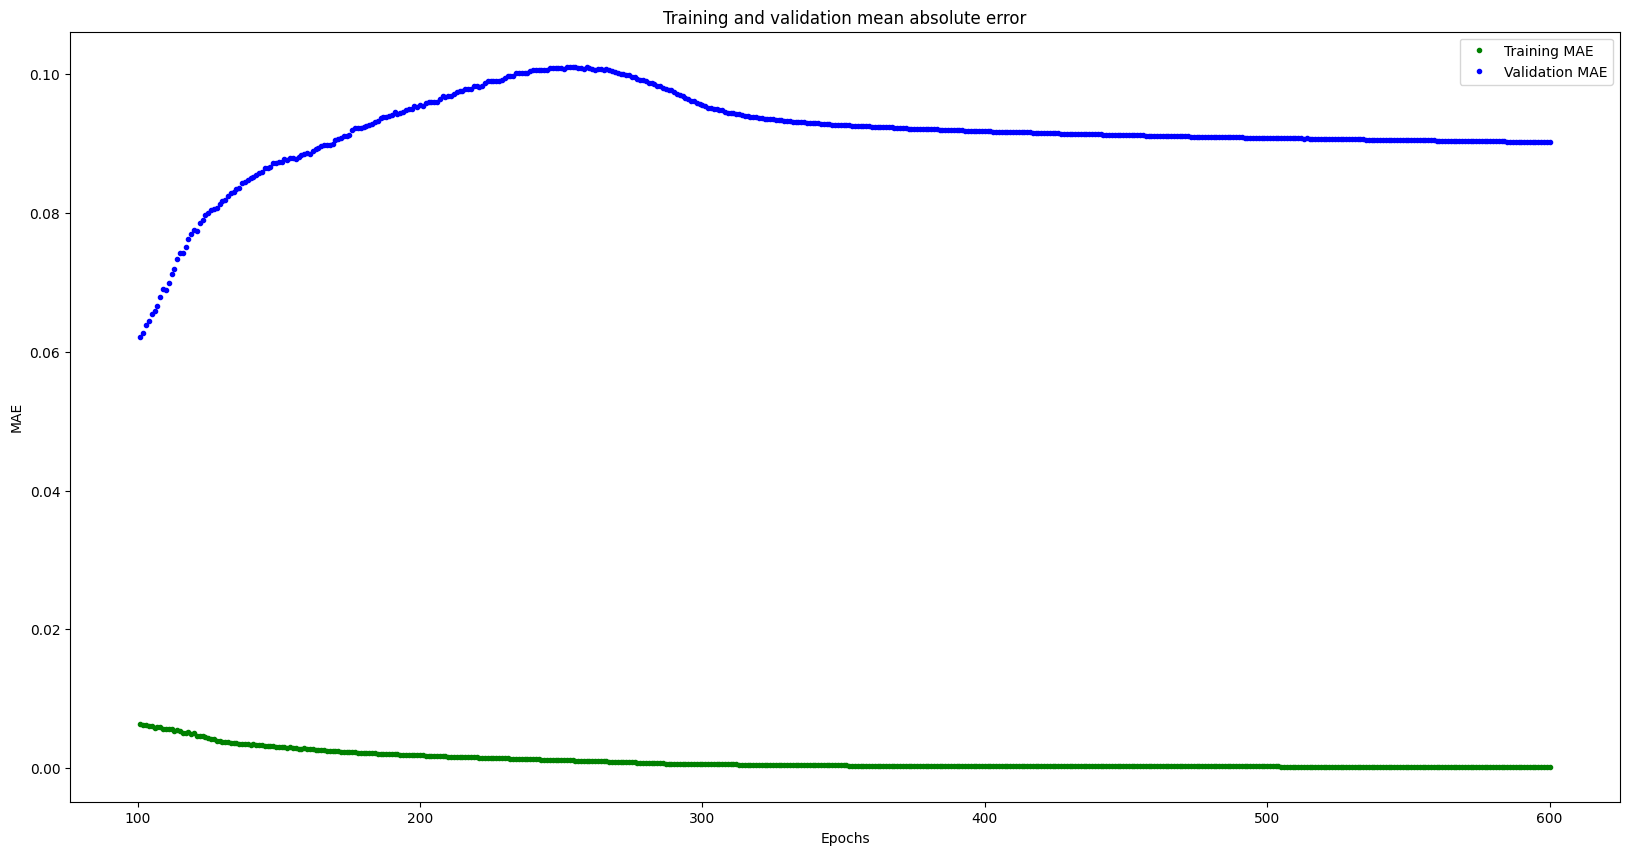

In [ ]:
# graph of mean absolute error
mae = history.history['mae']
val_mae = history.history['val_mae']
plt.plot(epochs[SKIP:], mae[SKIP:], 'g.', label='Training MAE')
plt.plot(epochs[SKIP:], val_mae[SKIP:], 'b.', label='Validation MAE')
plt.title('Training and validation mean absolute error')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()
plt.show()


### Run with Test Data
Put our test data into the model and plot the predictions


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Test accuracy: 80.56%


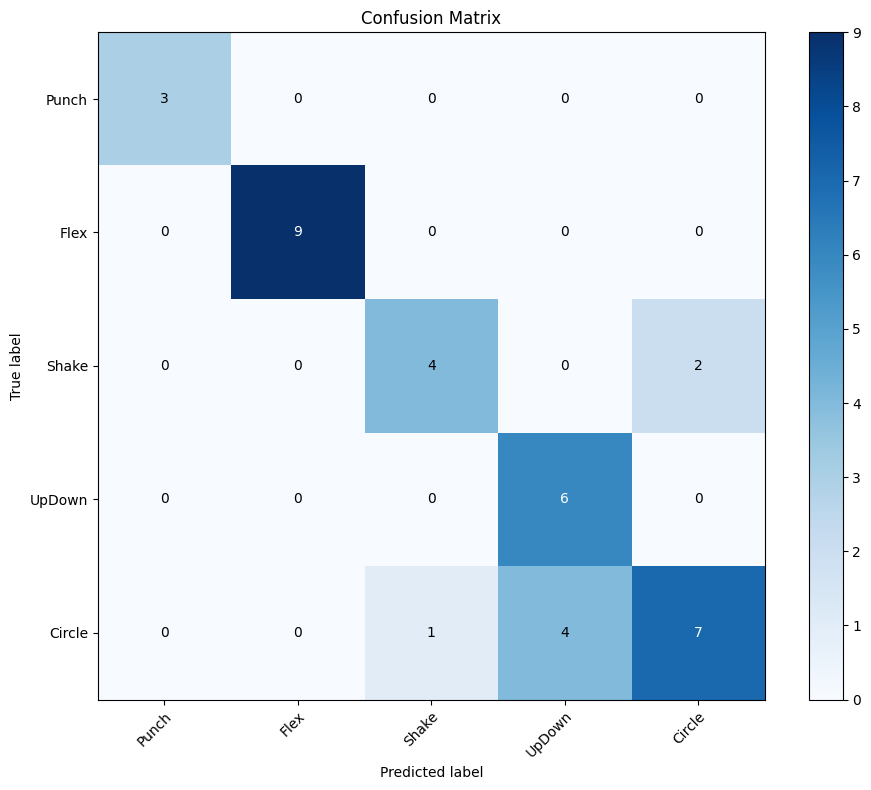

In [ ]:
evaluate_model(model, inputs_test, outputs_test, GESTURES)

# Convert the Trained Model to Tensor Flow Lite

The next cell converts the model to TFlite format. The size in bytes of the model is also printed out.

In [ ]:
# Convert the model to the TensorFlow Lite format without quantization
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Save the model to disk
open("gesture_model.tflite", "wb").write(tflite_model)

import os
basic_model_size = os.path.getsize("gesture_model.tflite")
print("Model is %d bytes" % basic_model_size)



Saved artifact at '/tmp/tmpcaxubb0g'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(1, 714), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(1, 2), dtype=tf.float32, name=None)
Captures:
  137012099660496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137012099660688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137012099659920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137012076103824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137012076103440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137012076104400: TensorSpec(shape=(), dtype=tf.resource, name=None)
Model is 148204 bytes


## Export Model Parameters for Arduino

The next cell exports the trained model weights, biases, normalization parameters,
and gesture names as a C header file for direct Arduino deployment.

In [ ]:
import os

export_model_params(model, norm_means, norm_stds, GESTURES, "model_params.h")

model_h_size = os.path.getsize("model_params.h")
print(f"Header file, model_params.h, is {model_h_size:,} bytes.")
print("\nOpen the side panel (refresh if needed). Double click model_params.h to download the file.")

Header file, model_params.h, is 38,041 bytes.

Open the side panel (refresh if needed). Double click model_params.h to download the file.


# Classifying IMU Data

Now it's time to switch back to the tutorial instructions and run our new model on the Arduino Nano 33 BLE Sense to classify the accelerometer and gyroscope data.
